# Sportsbook Consensus & Best Line Finder
**NFL 2025 Season — Notebook 3**

> **Context:** Notebooks 1 and 2 established that the 7-book sportsbook consensus is a more accurate probability model than ESPN alone. This notebook goes one level deeper — comparing the 7 books *against each other* to answer a question every serious bettor asks: does it matter which book you use, and how much is line shopping actually worth?

---

## Notebook Roadmap

| # | Section | What | Why |
|---|---------|------|-----|
| 1 | **Setup** | Load data, define helper functions | Baseline cleaning; convert EVEN entries, cast to numeric |
| 2 | **Best Line Frequency** | Which book posted the best available odds most often across 285 games | Answers: where should a disciplined line-shopper look first? |
| 3 | **The Bet365 Paradox** | Bet365 leads both best-line and worst-line frequency — investigate why | High frequency in both signals high variance, not consistent generosity |
| 4 | **Book Deviation From Consensus** | Mean signed deviation of each book's implied probability from the 7-book average | A book consistently above consensus is systematically more generous; below is worse for bettors |
| 5 | **Line Shopping Value** | Dollar gap between best and worst available line per game; cumulative season total | Most actionable finding: how much does loyalty to one book cost? |
| 6 | **Opener vs. Closing Line Movement** | Opening moneyline and spread vs. 7-book closing consensus | Lines move because money comes in — direction and magnitude bridge into Notebook 6 sharp money analysis |
| 7 | **Export** | Save all outputs to CSV | Handoff for Notebooks 6 and 7 |

---

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_data, BOOKS

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load ────────────────────────────────────────────────────────────────────
df = load_data('../data/nfl2025_complete.xlsx')

for col in df.columns:
    if '_spread' in col or 'total_line' in col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Helper functions ─────────────────────────────────────────────────────────
def ml_to_decimal(ml):
    """American moneyline → decimal odds. -150 → 1.667, +200 → 3.000"""
    if pd.isna(ml): return np.nan
    ml = float(ml)
    return ml/100 + 1 if ml > 0 else 100/abs(ml) + 1

def ml_to_prob(ml):
    """American moneyline → raw implied probability (includes vig)."""
    if pd.isna(ml): return np.nan
    ml = float(ml)
    return 100/(ml+100) if ml > 0 else abs(ml)/(abs(ml)+100)

# Column maps
away_ml_cols = {b: f'{b}_away_ml' for b in BOOKS}
home_ml_cols = {b: f'{b}_home_ml' for b in BOOKS}

print(f'Games: {len(df)} | Books: {BOOKS}')
df[['away_team','home_team','opener_away_ml'] + [f'{b}_away_ml' for b in BOOKS[:3]]].head(4)

Games: 285 | Books: ['bet365', 'si', 'betway', 'betmgm', 'fanduel', 'caesars', 'draftkings']


,away_team,home_team,opener_away_ml,bet365_away_ml,si_away_ml,betway_away_ml
0,Dallas Cowboys,Philadelphia Eagles,235,325,350,350
1,Kansas City Chiefs,Los Angeles Chargers,-180,-170,-165,-175
2,Carolina Panthers,Jacksonville Jaguars,130,185,185,185
3,Pittsburgh Steelers,New York Jets,-160,-167,-160,-165


## 2. Best Line Frequency

**What:** For every game, identify which of the 7 books posted the highest moneyline on the away side and on the home side. Higher moneyline = better odds for the bettor on that side.

**Why higher = better:** A +200 line pays $200 profit on a $100 bet. A +185 on the same outcome at another book pays only $185. The gap is pure value destroyed by not shopping.

**Figure meaning:** The bars show how often each book was the single best-priced option across all 285 games. A book leading this chart is where a disciplined line-shopper would find the best price most often.

In [2]:
def best_book(row, col_map):
    vals = {b: row[col] for b, col in col_map.items() if not pd.isna(row[col])}
    return max(vals, key=vals.get) if vals else None

def worst_book(row, col_map):
    vals = {b: row[col] for b, col in col_map.items() if not pd.isna(row[col])}
    return min(vals, key=vals.get) if vals else None

df['best_away_book']  = df.apply(lambda r: best_book(r, away_ml_cols), axis=1)
df['worst_away_book'] = df.apply(lambda r: worst_book(r, away_ml_cols), axis=1)
df['best_home_book']  = df.apply(lambda r: best_book(r, home_ml_cols), axis=1)
df['worst_home_book'] = df.apply(lambda r: worst_book(r, home_ml_cols), axis=1)

freq = pd.DataFrame({
    'Best Away':  df['best_away_book'].value_counts(),
    'Best Home':  df['best_home_book'].value_counts(),
    'Worst Away': df['worst_away_book'].value_counts(),
}).fillna(0).astype(int)
freq['Best Total'] = freq['Best Away'] + freq['Best Home']
freq = freq.sort_values('Best Total', ascending=False)

print('Best & Worst Line Frequency (285 games):')
freq

Best & Worst Line Frequency (285 games):


,Best Away,Best Home,Worst Away,Best Total
bet365,88,115,110,203
fanduel,48,40,44,88
betway,45,37,26,82
draftkings,39,40,51,79
si,43,35,28,78
caesars,13,9,18,22
betmgm,9,9,8,18


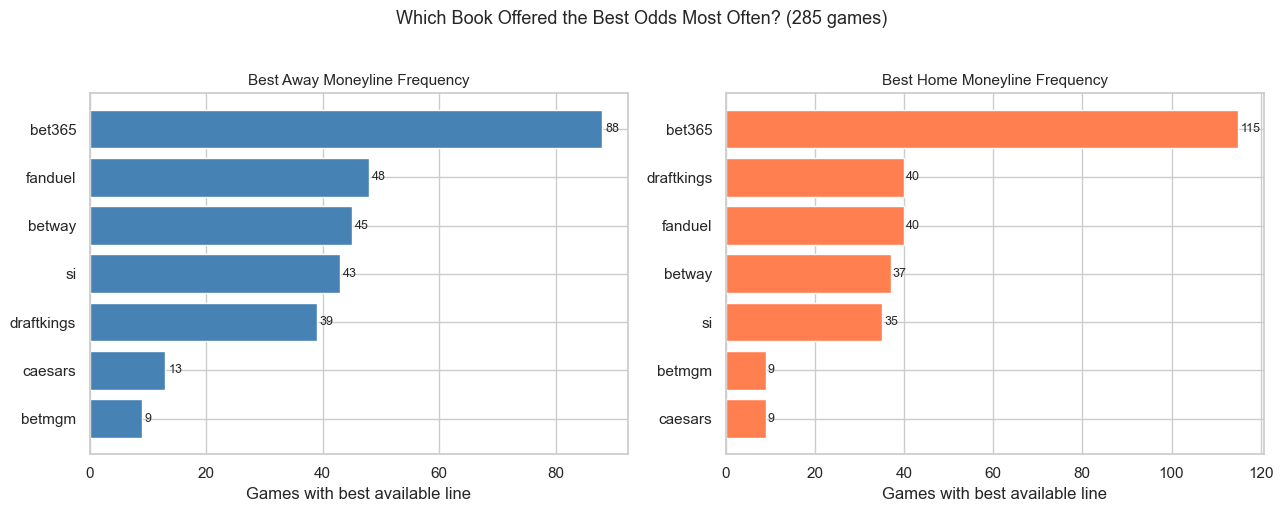

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title, color in [
    (axes[0], 'Best Away', 'Best Away Moneyline Frequency', 'steelblue'),
    (axes[1], 'Best Home', 'Best Home Moneyline Frequency', 'coral'),
]:
    data = freq[col].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Games with best available line')
    for i, v in enumerate(data.values):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.suptitle('Which Book Offered the Best Odds Most Often? (285 games)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. The Bet365 Paradox

**What:** Bet365 leads best-line frequency *and* worst-line frequency. This section diagnoses why.

**Why it matters:** A book that tops both lists is not the most consistently generous — it is the most volatile. Its lines deviate furthest from the market consensus in both directions. Understanding this prevents the naive conclusion that Bet365 is simply the best book to use.

**Figure meaning:**
- Left: Distribution of Bet365's decimal odds minus the 6-book average — a wide, centred distribution shows it swings far in both directions rather than sitting consistently above the market
- Right: Std dev of each book's divergence from peers — Bet365 is an outlier in volatility, not in generosity

In [4]:
variance_rows = []
for book in BOOKS:
    book_dec   = df[f'{book}_away_ml'].apply(ml_to_decimal)
    others_dec = df[[f'{b}_away_ml' for b in BOOKS if b != book]].apply(
        lambda row: pd.Series([ml_to_decimal(v) for v in row]).mean(), axis=1)
    diff = book_dec - others_dec
    variance_rows.append({
        'book':      book,
        'mean_diff': diff.mean(),
        'std_diff':  diff.std(),
        'abs_diff':  diff.abs().mean(),
        'above_avg': (diff > 0).sum(),
        'below_avg': (diff < 0).sum(),
    })

var_df = pd.DataFrame(variance_rows).set_index('book').sort_values('std_diff', ascending=False)

print('Variance of each book vs. its peers (away decimal odds):')
print('High std_diff = volatile pricing (swings both ways), not consistent generosity')
var_df.round(4)

Variance of each book vs. its peers (away decimal odds):
High std_diff = volatile pricing (swings both ways), not consistent generosity


,mean_diff,std_diff,abs_diff,above_avg,below_avg
book,,,,,
draftkings,0.1122,1.0252,0.3114,127,157
bet365,-0.2173,0.8329,0.3802,131,153
fanduel,0.1057,0.7231,0.2661,151,134
betway,0.0092,0.4039,0.1640,156,129
betmgm,0.0148,0.3548,0.1438,146,138
caesars,-0.0270,0.3526,0.1269,149,134
si,0.0025,0.3414,0.1433,145,138


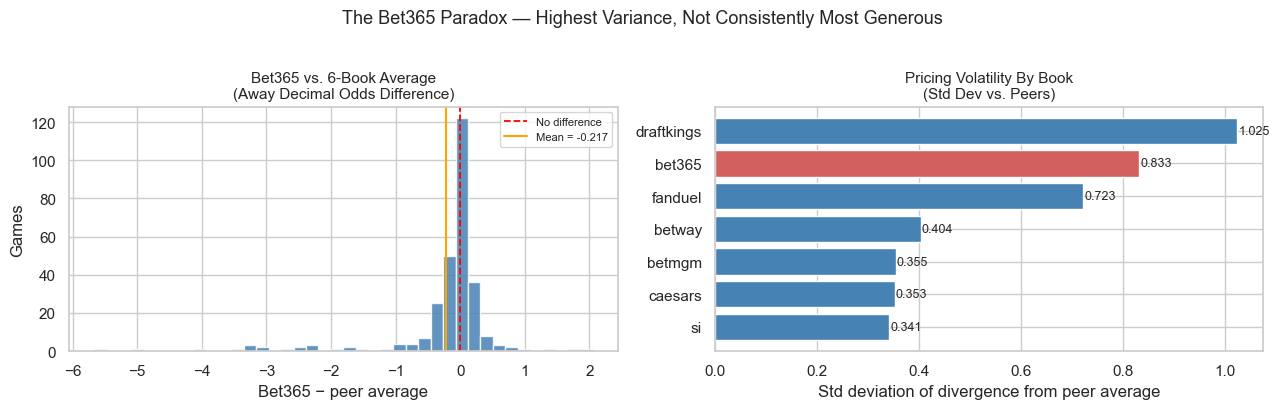

In [5]:
bet365_dec  = df['bet365_away_ml'].apply(ml_to_decimal)
others_dec  = df[[f'{b}_away_ml' for b in BOOKS if b != 'bet365']].apply(
    lambda row: pd.Series([ml_to_decimal(v) for v in row]).mean(), axis=1)
bet365_diff = bet365_dec - others_dec

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(bet365_diff.dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.3, label='No difference')
axes[0].axvline(bet365_diff.mean(), color='orange', linewidth=1.5,
                label=f'Mean = {bet365_diff.mean():.3f}')
axes[0].set_title('Bet365 vs. 6-Book Average\n(Away Decimal Odds Difference)', fontsize=11)
axes[0].set_xlabel('Bet365 − peer average')
axes[0].set_ylabel('Games')
axes[0].legend(fontsize=8)

std_sorted = var_df['std_diff'].sort_values(ascending=True)
colors = ['#d45f5f' if b == 'bet365' else 'steelblue' for b in std_sorted.index]
axes[1].barh(std_sorted.index, std_sorted.values, color=colors, edgecolor='white')
axes[1].set_title('Pricing Volatility By Book\n(Std Dev vs. Peers)', fontsize=11)
axes[1].set_xlabel('Std deviation of divergence from peer average')
for i, v in enumerate(std_sorted.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('The Bet365 Paradox — Highest Variance, Not Consistently Most Generous', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Book Deviation From Consensus

**What:** For each book, compute the mean signed difference between its raw implied probability and the 7-book consensus probability. Positive = book prices the away team lower than the market average (better odds for away bettors). Negative = book prices the away team higher (worse odds).

**Why probability not decimal odds:** Using probability removes the asymmetry between favourites and underdogs. A book consistently offering +0.5pp better implied probability is genuinely more generous regardless of whether the team is -300 or +250.

**Figure meaning:** Green bars (positive) = this book is systematically more generous than the consensus on the away side. Red bars = worse for bettors. Only Bet365 and DraftKings sit above zero on average.

In [6]:
deviation_rows = []
for book in BOOKS:
    book_prob = df[f'{book}_away_ml'].apply(ml_to_prob)
    consensus_prob = df[[f'{b}_away_ml' for b in BOOKS]].apply(
        lambda row: pd.Series([ml_to_prob(v) for v in row]).mean(), axis=1)
    diff = book_prob - consensus_prob
    deviation_rows.append({
        'book':              book,
        'mean_signed_diff':  diff.mean(),
        'abs_diff':          diff.abs().mean(),
        'games_above':       (diff > 0).sum(),
        'games_below':       (diff < 0).sum(),
    })

dev_df = pd.DataFrame(deviation_rows).set_index('book').sort_values('mean_signed_diff', ascending=False)
print('Positive = book offers lower implied prob = more generous odds for away bettors')
dev_df.round(4)

Positive = book offers lower implied prob = more generous odds for away bettors


,mean_signed_diff,abs_diff,games_above,games_below
book,,,,
bet365,0.0087,0.0365,150,135
draftkings,0.0018,0.0235,153,132
fanduel,-0.0011,0.0227,130,155
si,-0.0022,0.0134,127,158
betmgm,-0.0022,0.0123,130,155
caesars,-0.0023,0.0119,125,160
betway,-0.0027,0.0150,122,163


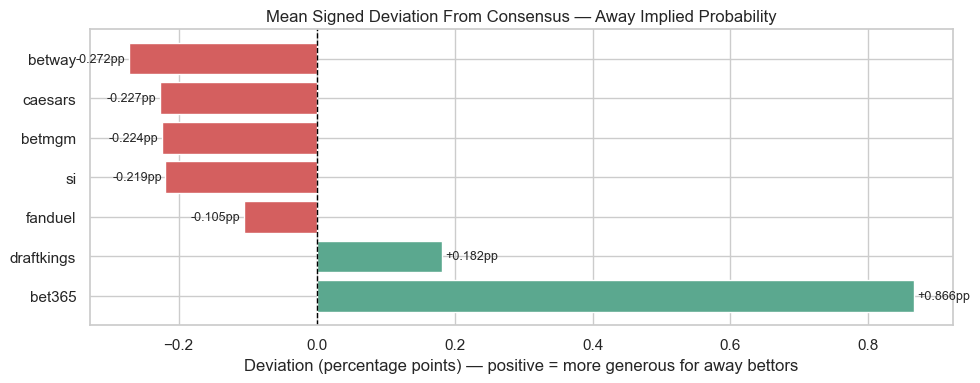

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#5ba88f' if v > 0 else '#d45f5f' for v in dev_df['mean_signed_diff']]
bars = ax.barh(dev_df.index, dev_df['mean_signed_diff'] * 100, color=colors, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Mean Signed Deviation From Consensus — Away Implied Probability', fontsize=12)
ax.set_xlabel('Deviation (percentage points) — positive = more generous for away bettors')
for bar, val in zip(bars, dev_df['mean_signed_diff']):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val*100 + offset, bar.get_y() + bar.get_height()/2,
            f'{val*100:+.3f}pp', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Line Shopping Value

**What:** For every game, compute the gap in decimal odds between the best and worst available book. Convert to dollar value per $100 stake. Aggregate across the full season to show the cumulative cost of not shopping lines.

**Why decimal odds:** The gap in decimal odds × $100 = exact extra profit from choosing the best book over the worst. This is a direct dollar figure.

**Figure meaning:**
- Left: Distribution of per-game line shopping gaps — most games have a modest gap but a tail of extreme divergences driven by Bet365's volatile pricing
- Right: Cumulative season value of always shopping for the best line vs. the worst — the running total of value available if you captured the full gap every game

In [8]:
def shopping_gap(row, col_map):
    decs = [ml_to_decimal(row[col]) for col in col_map.values()]
    decs = [d for d in decs if not np.isnan(d)]
    return (max(decs) - min(decs)) * 100 if len(decs) >= 2 else np.nan

df['away_gap'] = df.apply(lambda r: shopping_gap(r, away_ml_cols), axis=1)
df['home_gap'] = df.apply(lambda r: shopping_gap(r, home_ml_cols), axis=1)

print('Line Shopping Value — best vs. worst book per $100 bet:')
print(f'  Away side  mean: ${df["away_gap"].mean():.2f}   '
      f'median: ${df["away_gap"].median():.2f}   '
      f'max: ${df["away_gap"].max():.2f}')
print(f'  Home side  mean: ${df["home_gap"].mean():.2f}   '
      f'median: ${df["home_gap"].median():.2f}   '
      f'max: ${df["home_gap"].max():.2f}')
print(f'  Combined season total: ${(df["away_gap"].sum() + df["home_gap"].sum()):.2f}')
print()

print('Top 5 games with largest away-side line shopping gap:')
top5 = df.nlargest(5, 'away_gap')[['week','away_team','home_team','away_gap']].copy()
top5['away_gap'] = top5['away_gap'].map('${:.2f}'.format)
top5.reset_index(drop=True)

Line Shopping Value — best vs. worst book per $100 bet:
  Away side  mean: $69.53   median: $27.04   max: $1090.00
  Home side  mean: $45.50   median: $17.98   max: $1195.00
  Combined season total: $32784.95

Top 5 games with largest away-side line shopping gap:


,week,away_team,home_team,away_gap
0,10,Arizona Cardinals,Seattle Seahawks,$1090.00
1,3,Miami Dolphins,Buffalo Bills,$1050.00
2,9,New Orleans Saints,Los Angeles Rams,$1025.00
3,2,Cleveland Browns,Baltimore Ravens,$775.00
4,18,Los Angeles Chargers,Denver Broncos,$675.00


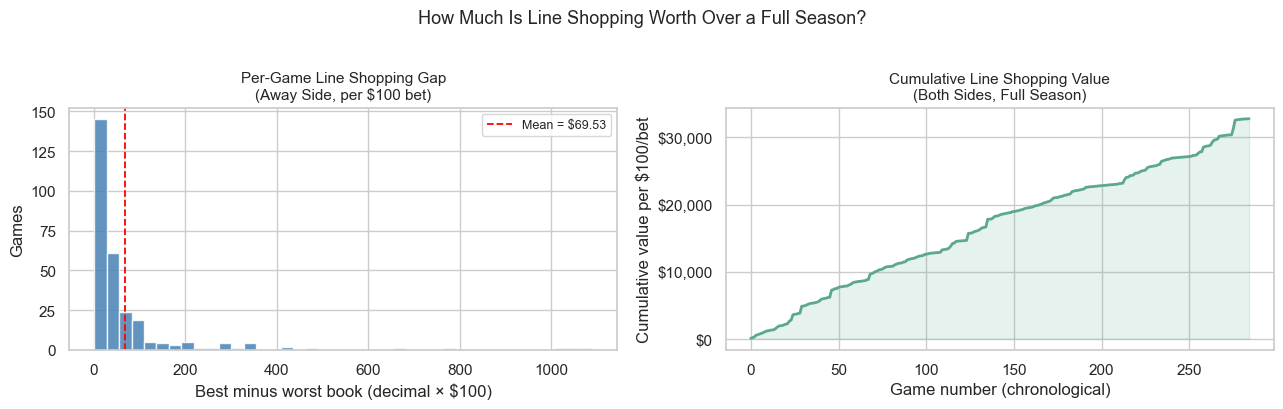

In [9]:
week_order = list(range(1, 19)) + ['WC', 'DIV', 'CC', 'SB']
week_map   = {w: i for i, w in enumerate(week_order)}
df['week_num'] = df['week'].map(week_map)
df_sorted = df.sort_values('week_num')
cumulative = (df_sorted['away_gap'] + df_sorted['home_gap']).cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['away_gap'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['away_gap'].mean(), color='red', linestyle='--', linewidth=1.3,
                label=f'Mean = ${df["away_gap"].mean():.2f}')
axes[0].set_title('Per-Game Line Shopping Gap\n(Away Side, per $100 bet)', fontsize=11)
axes[0].set_xlabel('Best minus worst book (decimal × $100)')
axes[0].set_ylabel('Games')
axes[0].legend(fontsize=9)

axes[1].plot(range(len(cumulative)), cumulative.values, color='#5ba88f', linewidth=2)
axes[1].fill_between(range(len(cumulative)), cumulative.values, alpha=0.15, color='#5ba88f')
axes[1].set_title('Cumulative Line Shopping Value\n(Both Sides, Full Season)', fontsize=11)
axes[1].set_xlabel('Game number (chronological)')
axes[1].set_ylabel('Cumulative value per $100/bet')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('How Much Is Line Shopping Worth Over a Full Season?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Opener vs. Closing Line Movement

**What:** Compare the opening moneyline and spread (the book's first price before public betting) to the 7-book closing consensus (the final market price at kickoff). Measure direction and magnitude of drift.

**Why this matters:** Lines move because money comes in and books adjust. A line that moves significantly toward a team — even when most public bettors are on the other side — is the classic sharp money signal. This section measures the aggregate pattern across the full season. Notebook 6 identifies the specific games where movement was most extreme and tests whether it predicted outcomes.

**Key concept — Closing Line Value (CLV):** If you bet the opener and the line subsequently moved in your favour before kickoff, you captured positive CLV. Consistently beating the closing line is the professional bettor's gold standard of edge, independent of short-run outcomes.

**Figure meaning:**
- Top row: Distribution of moneyline and spread movement — positive ML movement = closing line more generous for away bettor than opener
- Bottom row: Total line movement (closing consensus − opener) and the top games with the largest spread shifts

In [10]:
# Moneyline movement (decimal)
df['opener_away_dec']  = df['opener_away_ml'].apply(ml_to_decimal)
df['closing_away_dec'] = df[[f'{b}_away_ml' for b in BOOKS]].apply(
    lambda row: pd.Series([ml_to_decimal(v) for v in row]).mean(), axis=1)
df['ml_movement'] = df['closing_away_dec'] - df['opener_away_dec']

# Spread movement (points)
df['closing_spread']   = df[[f'{b}_away_spread' for b in BOOKS]].mean(axis=1)
df['spread_movement']  = df['closing_spread'] - df['opener_away_spread']

# Total line movement (points)
df['closing_total']    = df[[f'{b}_total_line' for b in BOOKS]].mean(axis=1)
df['total_movement']   = df['closing_total'] - df['opener_total_line']

print('=== MONEYLINE MOVEMENT (decimal odds) ===')
print(f'  Mean     : {df["ml_movement"].mean():.4f}')
print(f'  Std dev  : {df["ml_movement"].std():.4f}')
print(f'  Favoured away (positive) : {(df["ml_movement"] > 0).sum()} games')
print(f'  Favoured home (negative) : {(df["ml_movement"] < 0).sum()} games')
print()
print('=== SPREAD MOVEMENT (points) ===')
print(f'  Mean     : {df["spread_movement"].mean():.3f} pts  (positive = spread widened toward home)')
print(f'  Std dev  : {df["spread_movement"].std():.3f} pts')
print(f'  Moved toward away (tightened)  : {(df["spread_movement"] < 0).sum()} games')
print(f'  Moved toward home (widened)    : {(df["spread_movement"] > 0).sum()} games')
print(f'  Max single game movement       : {df["spread_movement"].abs().max():.1f} pts')
print()
print('=== TOTAL LINE MOVEMENT (points) ===')
print(f'  Mean     : {df["total_movement"].mean():.3f} pts  (negative = totals drifted down = sharp under lean)')
print(f'  Moved up   : {(df["total_movement"] > 0).sum()} games')
print(f'  Moved down : {(df["total_movement"] < 0).sum()} games')

=== MONEYLINE MOVEMENT (decimal odds) ===
  Mean     : 0.1996
  Std dev  : 0.7748
  Favoured away (positive) : 162 games
  Favoured home (negative) : 122 games

=== SPREAD MOVEMENT (points) ===
  Mean     : 0.024 pts  (positive = spread widened toward home)
  Std dev  : 2.605 pts
  Moved toward away (tightened)  : 120 games
  Moved toward home (widened)    : 150 games
  Max single game movement       : 12.7 pts

=== TOTAL LINE MOVEMENT (points) ===
  Mean     : -0.378 pts  (negative = totals drifted down = sharp under lean)
  Moved up   : 110 games
  Moved down : 157 games


In [11]:
print('Top 8 games with largest spread movement:')
top_move = (
    df[['week','away_team','home_team','opener_away_spread',
        'closing_spread','spread_movement','winner']]
    .assign(abs_move=df['spread_movement'].abs())
    .nlargest(8, 'abs_move')
    .drop('abs_move', axis=1)
    .reset_index(drop=True)
)
top_move

Top 8 games with largest spread movement:


,week,away_team,home_team,opener_away_spread,closing_spread,spread_movement,winner
0,5,Houston Texans,Baltimore Ravens,9.5000,-3.2143,-12.7143,Houston Texans
1,8,Miami Dolphins,Atlanta Falcons,-5.5000,5.1429,10.6429,Miami Dolphins
2,17,Arizona Cardinals,Cincinnati Bengals,5.5000,-5.0000,-10.5000,Cincinnati Bengals
3,17,Denver Broncos,Kansas City Chiefs,-6.0000,-16.3571,-10.3571,Denver Broncos
4,3,Indianapolis Colts,Tennessee Titans,1.5000,-7.6429,-9.1429,Indianapolis Colts
5,15,Indianapolis Colts,Seattle Seahawks,4.0000,12.6429,8.6429,Seattle Seahawks
6,14,Cincinnati Bengals,Buffalo Bills,7.0000,-1.1429,-8.1429,Buffalo Bills
7,18,Los Angeles Chargers,Denver Broncos,7.5000,15.5000,8.0000,Denver Broncos


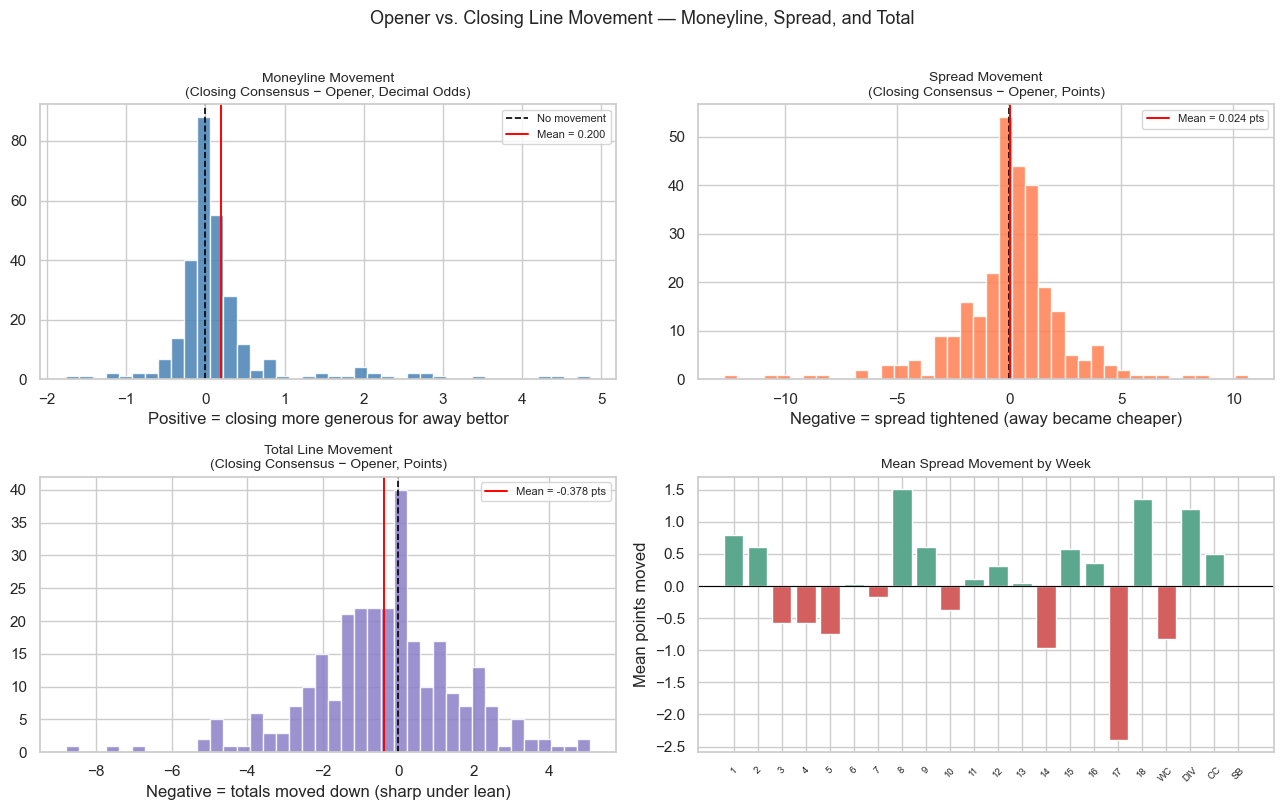

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ML movement
axes[0,0].hist(df['ml_movement'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='No movement')
axes[0,0].axvline(df['ml_movement'].mean(), color='red', linewidth=1.4,
                  label=f'Mean = {df["ml_movement"].mean():.3f}')
axes[0,0].set_title('Moneyline Movement\n(Closing Consensus − Opener, Decimal Odds)', fontsize=10)
axes[0,0].set_xlabel('Positive = closing more generous for away bettor')
axes[0,0].legend(fontsize=8)

# Spread movement
axes[0,1].hist(df['spread_movement'].dropna(), bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[0,1].axvline(df['spread_movement'].mean(), color='red', linewidth=1.4,
                  label=f'Mean = {df["spread_movement"].mean():.3f} pts')
axes[0,1].set_title('Spread Movement\n(Closing Consensus − Opener, Points)', fontsize=10)
axes[0,1].set_xlabel('Negative = spread tightened (away became cheaper)')
axes[0,1].legend(fontsize=8)

# Total movement
axes[1,0].hist(df['total_movement'].dropna(), bins=40, color='#8a7fc7', edgecolor='white', alpha=0.85)
axes[1,0].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1,0].axvline(df['total_movement'].mean(), color='red', linewidth=1.4,
                  label=f'Mean = {df["total_movement"].mean():.3f} pts')
axes[1,0].set_title('Total Line Movement\n(Closing Consensus − Opener, Points)', fontsize=10)
axes[1,0].set_xlabel('Negative = totals moved down (sharp under lean)')
axes[1,0].legend(fontsize=8)

# Spread movement by week
weekly_move = df.groupby('week_num').agg(
    week=('week','first'),
    mean_spread_move=('spread_movement','mean'),
    n=('spread_movement','count')
).reset_index()
colors_w = ['#5ba88f' if v >= 0 else '#d45f5f' for v in weekly_move['mean_spread_move']]
axes[1,1].bar(range(len(weekly_move)), weekly_move['mean_spread_move'], color=colors_w, edgecolor='white')
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_xticks(range(len(weekly_move)))
axes[1,1].set_xticklabels(weekly_move['week'].astype(str), rotation=45, fontsize=7)
axes[1,1].set_title('Mean Spread Movement by Week', fontsize=10)
axes[1,1].set_ylabel('Mean points moved')

plt.suptitle('Opener vs. Closing Line Movement — Moneyline, Spread, and Total', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Export

In [13]:
os.makedirs('../outputs', exist_ok=True)

# Best line frequency
freq.to_csv('../outputs/3_best_line_frequency.csv')

# Book variance vs. peers
var_df.to_csv('../outputs/3_book_variance.csv')

# Book deviation from consensus
dev_df.to_csv('../outputs/3_book_deviation.csv')

# Per-game line shopping + movement
export_cols = [
    'week', 'away_team', 'home_team', 'winner',
    'best_away_book', 'best_home_book', 'worst_away_book',
    'away_gap', 'home_gap',
    'opener_away_ml', 'closing_away_dec', 'ml_movement',
    'opener_away_spread', 'closing_spread', 'spread_movement',
    'opener_total_line', 'closing_total', 'total_movement',
]
df[export_cols].to_csv('../outputs/3_line_shopping.csv', index=False)

print('Exported:')
print(f'  3_best_line_frequency.csv — {len(freq)} books')
print(f'  3_book_variance.csv       — {len(var_df)} books')
print(f'  3_book_deviation.csv      — {len(dev_df)} books')
print(f'  3_line_shopping.csv       — {len(df)} games')

Exported:
  3_best_line_frequency.csv — 7 books
  3_book_variance.csv       — 7 books
  3_book_deviation.csv      — 7 books
  3_line_shopping.csv       — 285 games


---

## Notebook 3 — Key Findings

### 1. Best Line Frequency — Bet365 Dominates, But Not Uniformly

Across all 285 games, **Bet365 offered the best available moneyline most often** — the best away line in 88 games and best home line in 115 games, giving a combined best-line total of **203/570 opportunities (35.6%)**. FanDuel, Betway, and DraftKings were a distant cluster in second place at 79–88 combined.

| Book | Best Away | Best Home | Best Total | Worst Away |
|------|-----------|-----------|------------|------------|
| **Bet365** | **88** | **115** | **203** | **110** |
| FanDuel | 48 | 40 | 88 | 44 |
| Betway | 45 | 37 | 82 | 26 |
| DraftKings | 39 | 40 | 79 | 51 |
| SI | 43 | 35 | 78 | 28 |
| Caesars | 13 | 9 | 22 | 18 |
| BetMGM | 9 | 9 | 18 | 8 |

---

### 2. The Bet365 Paradox — Volatile, Not Generous

Bet365 also **leads worst-line frequency with 110 games on the away side** — the same book topping both best and worst lists. The explanation is pricing volatility, not consistent generosity. Bet365 has a **standard deviation of 0.833 decimal odds** versus the peer average, compared to SI's 0.341 and Caesars' 0.353. It takes aggressive positions that diverge sharply from the consensus in both directions.

The practical takeaway is that **DraftKings is the most reliably above-consensus book** (+0.0018pp mean signed deviation, above consensus in 153/285 games) while Bet365's advantage is unreliable — it swings both ways with equal frequency.

| Book | Mean Signed Diff | Std Dev vs. Peers | Games Above Consensus |
|------|-----------------|-------------------|----------------------|
| **Bet365** | **+0.0087pp** | **0.833** | 150/285 |
| DraftKings | +0.0018pp | 1.025 | 153/285 |
| FanDuel | −0.0011pp | 0.723 | 130/285 |
| SI | −0.0022pp | 0.341 | 127/285 |
| BetMGM | −0.0022pp | 0.355 | 130/285 |
| Caesars | −0.0023pp | 0.353 | 125/285 |
| Betway | −0.0027pp | 0.404 | 122/285 |

**Only Bet365 and DraftKings sit above the consensus on average.** All five other books are systematically slightly worse than the market average for bettors.

---

### 3. Line Shopping Value — 2,785 Left on the Table

If a bettor always placed 00 on the best available away-side line rather than the worst across all 285 games:

- **Away side:** mean gap of **9.53/game**, median 7.04, max ,090
- **Home side:** mean gap of **5.50/game**, median 7.98, max ,195
- **Combined season total: 2,785** — the theoretical value destroyed by always using the worst book instead of the best

The median gap (7 away, 8 home) is the more realistic figure for most games. The mean is inflated by extreme outliers driven by Bet365's volatile pricing on heavy underdogs.

**Top 5 games with largest away-side line shopping gap:**

| Week | Away | Home | Gap |
|------|------|------|-----|
| 10 | Arizona Cardinals | Seattle Seahawks | **,090** |
| 3 | Miami Dolphins | Buffalo Bills | ,050 |
| 9 | New Orleans Saints | Los Angeles Rams | ,025 |
| 2 | Cleveland Browns | Baltimore Ravens | 75 |
| 18 | Los Angeles Chargers | Denver Broncos | 75 |

All five extreme-gap games involve heavy underdogs — the exact scenarios where Bet365's volatile pricing creates the widest divergences from its competitors.

---

### 4. Opener vs. Closing Line Movement

**Moneyline:** The closing consensus was more generous for away bettors than the opener in **162/284 games** (57%), with a mean movement of +0.20 decimal odds. Lines drift slightly toward underdogs on average — meaning opening lines offer slightly better value for betting favourites.

**Spread:** Mean movement of just **+0.024 points** — effectively zero systematic drift. But the distribution is wide (std dev 2.6 pts), meaning individual games can move dramatically. The spread moved toward the home team in 150/285 games vs. 120 toward the away team.

**Totals:** Mean movement of **−0.378 points** — totals drifted slightly lower across the season. 157 games saw the total move down vs. 110 up. This is consistent with sharp bettors having a systematic under lean — known in the industry as the public tending to overestimate scoring.

**Top 3 largest spread movements:**

| Week | Away | Home | Opener | Closing | Move | Winner |
|------|------|------|--------|---------|------|---------|
| 5 | Houston Texans | Baltimore Ravens | +9.5 | −3.2 | **−12.7 pts** | Houston Texans |
| 8 | Miami Dolphins | Atlanta Falcons | −5.5 | +5.1 | +10.6 pts | Miami Dolphins |
| 17 | Arizona Cardinals | Cincinnati Bengals | +5.5 | −5.0 | −10.5 pts | Cincinnati Bengals |

The Houston–Baltimore game (Week 5, −12.7 pts) is the most extreme line movement in the dataset. The Texans opened as 9.5-point underdogs and closed as 3.2-point favourites — a 12.7-point swing driven by significant sharp action. Houston won the game outright, validating the sharp side. This game will be revisited in **Notebook 6 (Sharp Money Signals)** as the centrepiece of the reverse line movement analysis.

---

### Summary Table

| Metric | Value |
|--------|-------|
| Best-line book (frequency) | Bet365 (203/570 opportunities) |
| Most reliable above-consensus | DraftKings (+0.0018pp mean) |
| Most volatile book | Bet365 (std dev 0.833) |
| Avg line shopping gap per game | 9.53 (away), 5.50 (home) |
| Season line shopping total | 2,785 |
| Closing ML better than opener | 162/284 games (57%) |
| Mean spread movement | +0.024 pts (negligible) |
| Mean total movement | −0.378 pts (sharp under lean) |
| Largest single spread move | 12.7 pts (HOU @ BAL, Week 5) |

> **Next:** Notebook 4 adds Polymarket as a fourth model alongside ESPN and the sportsbook consensus, and compares how a decentralised prediction market prices NFL games vs. traditional bookmakers.
